Import needed libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import pacmap
import pandas as pd
import numpy as np

import sys
import os

import unsupervizedClass
from models.unsupervised.dimReduction.dReduce import *

/home/hootdarcy/ChE7700/che7700env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1773516988.113948    6067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773516988.114369    6067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773516988.150618    6067 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler 

import custom data processing class
import data file

we only use stock names as the data labels and effectively do not use any of the other class data (such as industry type... etc..)

We transform the date type to a float to allow processing within numpy and clustering and DR methods


perform data transform for clustering and dimensionality reduction

split the data set into sub groups

In [2]:
data = unsupervizedClass.DataPreprocessing()
data = data.load_data('/home/hootdarcy/ChE7700/Stocks_Project/scripts/data/World-Stock-Prices-Dataset.csv')

labels = data[:,6:7]
print(labels)
data = data[:,0:6]
print(data)

dataDateFloat = data[:,0].astype('datetime64[s]').astype(float)
data[:,0] = dataDateFloat


scaler = StandardScaler().fit(data)
dataScaled = scaler.transform(data)

X_train,X_test,Y_train,Y_test = train_test_split( dataScaled, labels, test_size=0.15)

#hueYtrain = pd.DataFrame({'x': x_data, 'y': y_data, 'category': Y_train})
#hueYtest = pd.DataFrame({'x': x_data, 'y': y_data, 'category': Y_test})

# num_samples = dataScaled.shape[0]
# train_proportion = 0.7
# val_proportion = 0.15
# test_proportion = 0.15

# num_train = int(num_samples * train_proportion)
# num_val = int(num_samples * val_proportion)


# indices = np.arange(num_samples)
# np.random.seed(42) 
# np.random.shuffle(indices)

# train_indices = indices[:num_train]
# val_indices = indices[num_train:num_train + num_val]
# test_indices = indices[num_train + num_val:]

# train_data = dataScaled[train_indices]
# val_data = dataScaled[val_indices]
# test_data = dataScaled[test_indices]


print(f"Train data shape: {X_train.shape}")
print(f"Test data shape: {Y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test data shape: {Y_test.shape}")

                        Date        Open        High         Low       Close  \
0  2025-07-03 00:00:00-04:00    6.630000    6.740000    6.615000    6.640000   
1  2025-07-03 00:00:00-04:00  106.750000  108.370003  106.330101  107.339996   
2  2025-07-03 00:00:00-04:00  122.629997  123.050003  121.550003  121.930000   
3  2025-07-03 00:00:00-04:00  221.705002  224.009995  221.360001  223.410004   
4  2025-07-03 00:00:00-04:00  212.145004  214.649994  211.810104  213.550003   

     Volume Brand_Name Ticker Industry_Tag  Country  Dividends  Stock Splits  
0   4209664    peloton   PTON      fitness      usa        0.0           0.0  
1    560190      crocs   CROX     footwear      usa        0.0           0.0  
2     36600     adidas  ADDYY      apparel  germany        0.0           0.0  
3  29295154     amazon   AMZN   e-commerce      usa        0.0           0.0  
4  34697317      apple   AAPL   technology      usa        0.0           0.0  
[['peloton']
 ['crocs']
 ['adidas']
 ...
 ['t

/tmp/ipykernel_6067/2656060965.py:9: UserWarning: no explicit representation of timezones available for np.datetime64
  dataDateFloat = data[:,0].astype('datetime64[s]').astype(float)


Since the dataset is so large and we ran into computaional loads, we used the testing data set instead of the testing data set. 

In short we took a 15% random subset of the orginal stock dataset

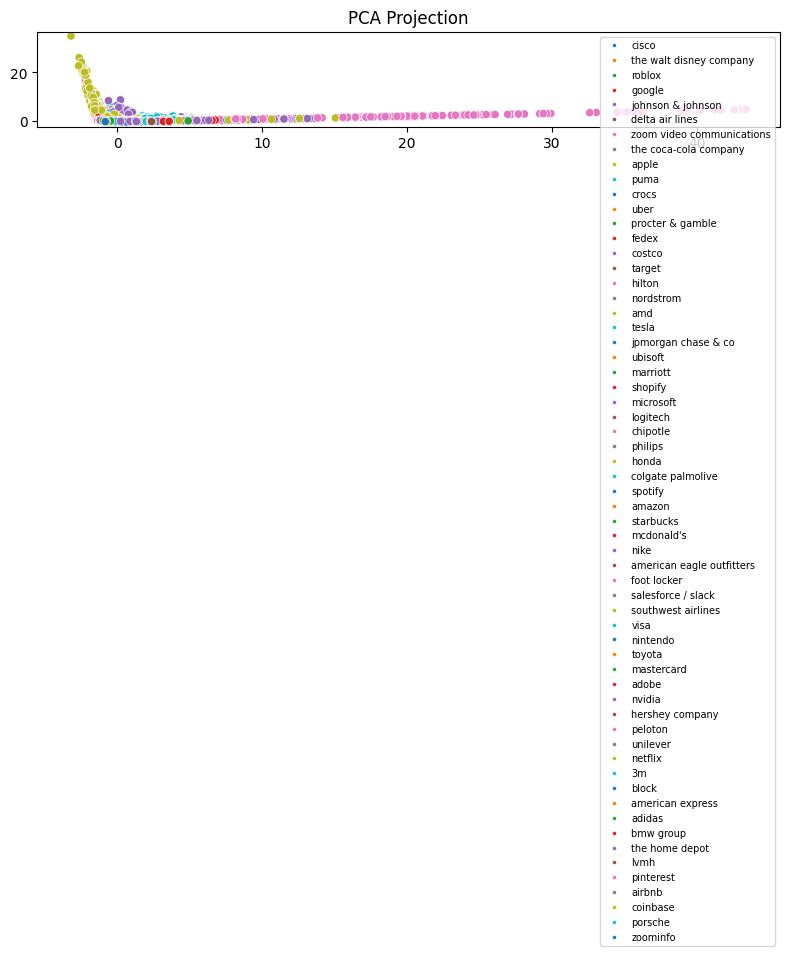

[[-1.02249773  0.52159432]
 [ 0.96038193 -0.40889337]
 [-0.15433803 -0.66004529]
 ...
 [-0.7777398   0.02171932]
 [-0.74913939 -0.4151908 ]
 [-0.82970128 -0.38349216]]
[-1.02249773  0.96038193 -0.15433803 ... -0.7777398  -0.74913939
 -0.82970128]
[ 0.52159432 -0.40889337 -0.66004529 ...  0.02171932 -0.4151908
 -0.38349216]


In [3]:
XPCA=graphPCA(X_test, 2, Y_test)

the PCA projection showed an interesting groupings

the code below is separating the different groups for futher investigation

In [25]:
print(XPCA)
merged_horizontal = np.concatenate((XPCA, Y_test), axis=1)
print(f"Horizontal Merge:\n{merged_horizontal}")

condition = (merged_horizontal[:,0] >5)
subarray =  merged_horizontal[condition]
print("Merged:")
print(subarray)

XPCAsub= subarray[:,[0,1]]
YPCAsub =subarray[:,2]

condition2 = (merged_horizontal[:,1] >3)
subarray2 =  merged_horizontal[condition2]
print("Merged:")
print(subarray2)

XPCAsub2= subarray2[:,[0,1]]
YPCAsub2 =subarray2[:,2]


condition3= (merged_horizontal[:, 0] <1) & (merged_horizontal[:, 1] <3)
subarray3 =  merged_horizontal[condition3]
print("Merged:")
print(subarray3)

XPCAsub3= subarray3[:,[0,1]]
YPCAsub3 =subarray3[:,2]

[[-1.02249773  0.52159432]
 [ 0.96038193 -0.40889337]
 [-0.15433803 -0.66004529]
 ...
 [-0.7777398   0.02171932]
 [-0.74913939 -0.4151908 ]
 [-0.82970128 -0.38349216]]
Horizontal Merge:
[[-1.02249773026811 0.5215943209648016 'cisco']
 [0.9603819252096293 -0.4088933713306003 'the walt disney company']
 [-0.15433803100539403 -0.6600452868705183 'roblox']
 ...
 [-0.7777398002409085 0.021719320257379472 'hershey company']
 [-0.7491393920501735 -0.41519079993011987 'american eagle outfitters']
 [-0.8297012804024423 -0.38349216311256185 'crocs']]
Merged:
[[33.056847015192865 3.383835767951235 'chipotle']
 [10.379203243378072 0.785050232712033 'chipotle']
 [5.431110357040548 0.07845299826423208 'netflix']
 ...
 [5.205934120103627 0.3049849177780047 'chipotle']
 [13.833873711466445 1.1746516063257542 'chipotle']
 [5.497009431390714 0.07742804166402133 'costco']]
Merged:
[[-1.1107540903768034 3.2547508813931967 'apple']
 [33.056847015192865 3.383835767951235 'chipotle']
 [-1.794106262954079 9.8

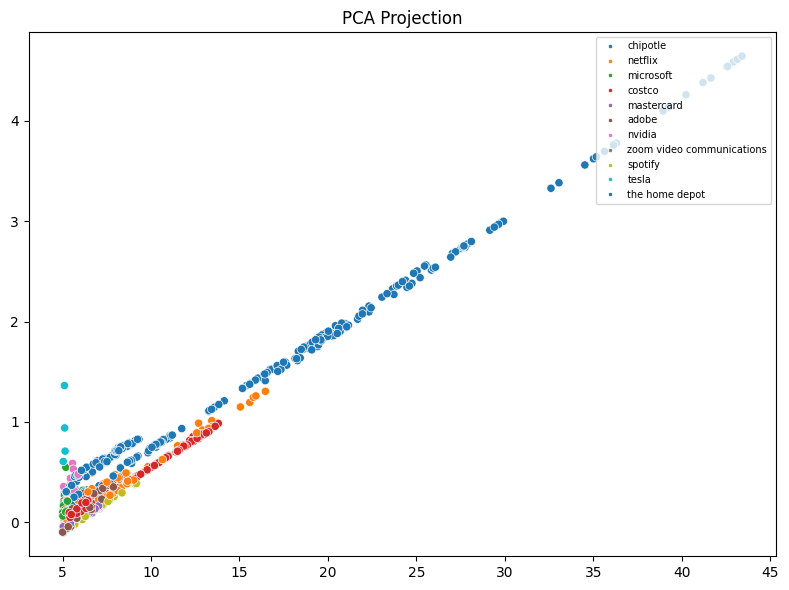

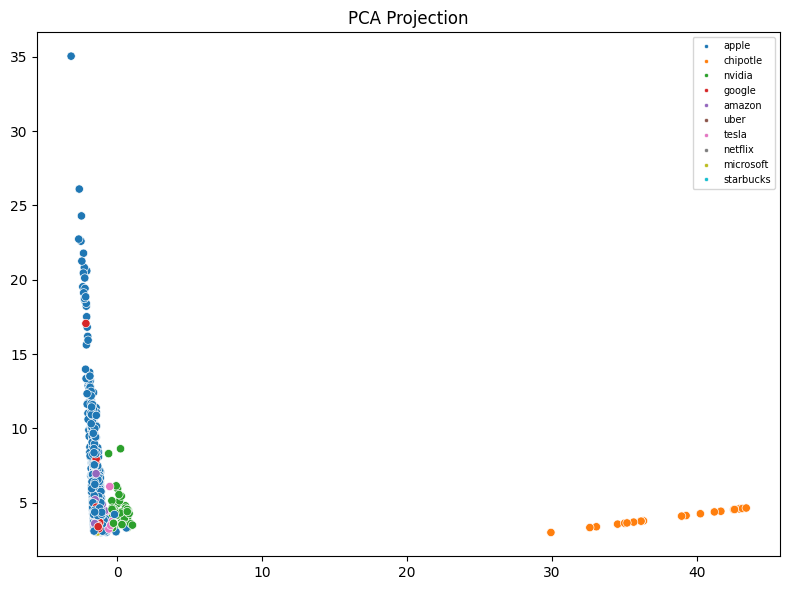

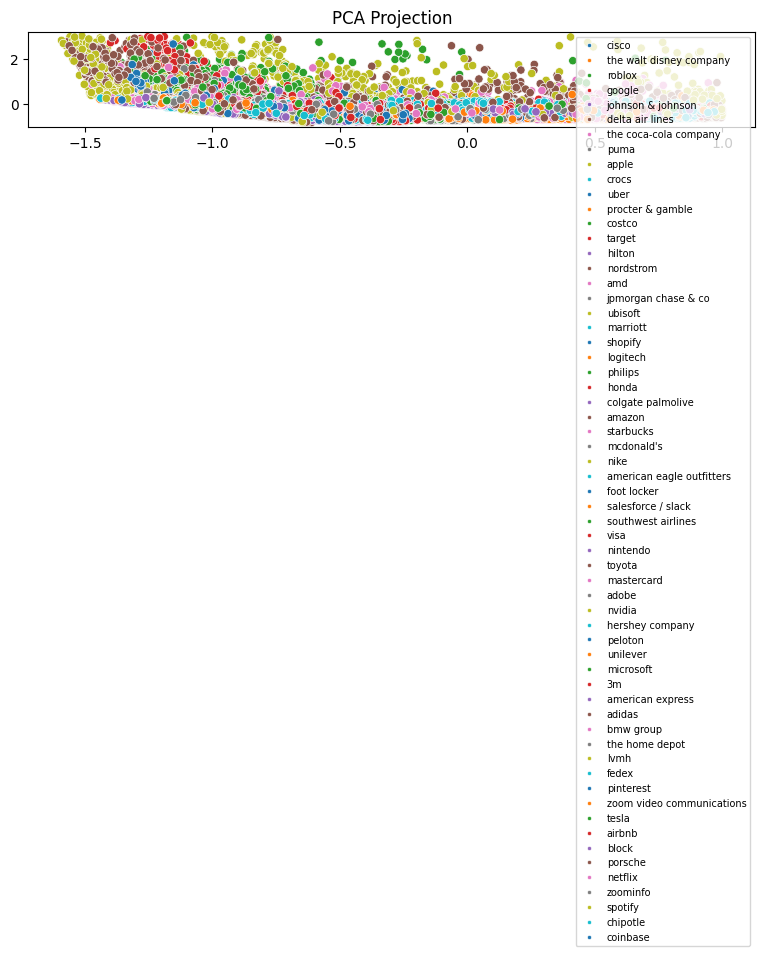

In [26]:
plt.figure(figsize=(8,6))
ax=sns.scatterplot(x=XPCAsub[:, 0], y=XPCAsub[:, 1], hue=YPCAsub.ravel(), palette="tab10")
sns.move_legend(ax, "upper right", fontsize=7, markerscale=0.5)

plt.title("PCA Projection")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
ax=sns.scatterplot(x=XPCAsub2[:, 0], y=XPCAsub2[:, 1], hue=YPCAsub2.ravel(), palette="tab10")
sns.move_legend(ax, "upper right", fontsize=7, markerscale=0.5)

plt.title("PCA Projection")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
ax=sns.scatterplot(x=XPCAsub3[:, 0], y=XPCAsub3[:, 1], hue=YPCAsub3.ravel(), palette="tab10")
sns.move_legend(ax, "upper right", fontsize=7, markerscale=0.5)

plt.title("PCA Projection")
plt.tight_layout()
plt.show()

PCA appears to out put two distinct nodes. 

Node 1 is roughly when the pricipal compoenet vector #1 is >5
Node 2 is roughly when the pricipal compoenet vector #2 is >3

We chose to use these two nodes to help us refine the data for supervised learning. We plan to build a regression model for both apple stock (node 2) and chipolte stock (node 1). Then compare these regression models with both stocks in node 1 and node 2 to compare predictive performance.

See breakdown below:
 
Node 2: model base stock = apple
Node 2: compare/test model stock = google
 
 
Node 1: model base stock = chipolte
Node 1: compare/test model stock = costco
 
 
potential test preduct costco stock closing price using node 1 (apple model) and test google stock closing price using node 2 (chipolte model)

In [4]:
print(Y_test)

[['target']
 ['tesla']
 ['logitech']
 ...
 ['microsoft']
 ['colgate palmolive']
 ['adobe']]


In [ ]:
print(y)

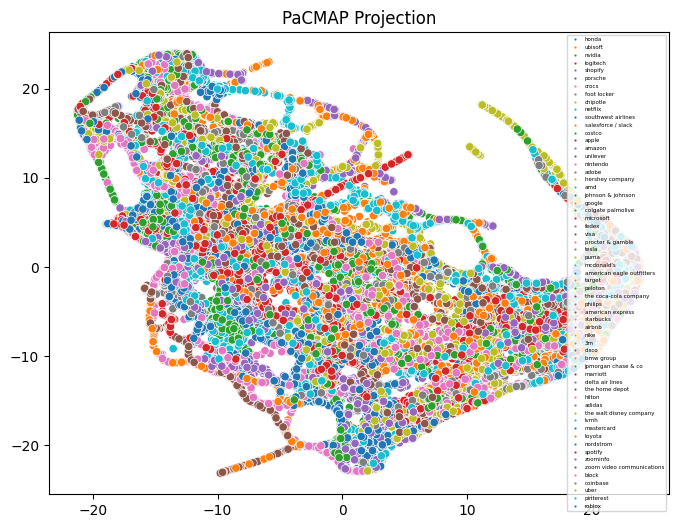

In [7]:
graphPaCMAP(X_test,Y_test)

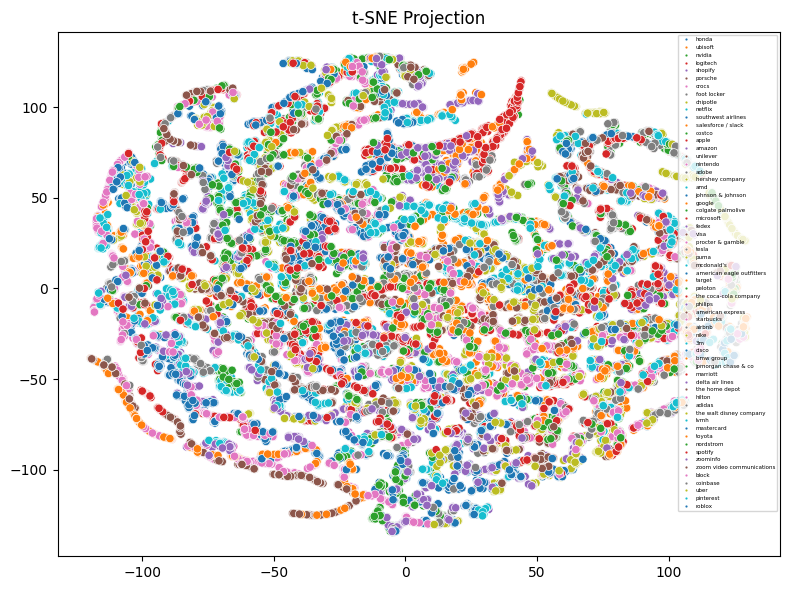

In [5]:
graphtSNE(X_test,Y_test)

/home/hootdarcy/ChE7700/che7700env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


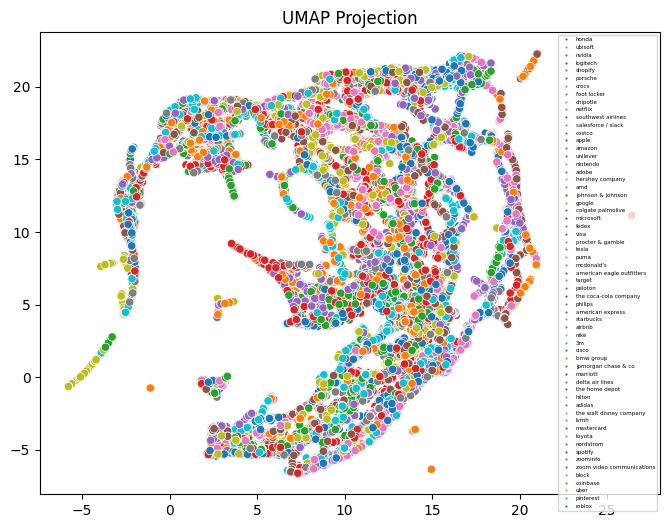

In [4]:
graphUMAP(X_test,Y_test)

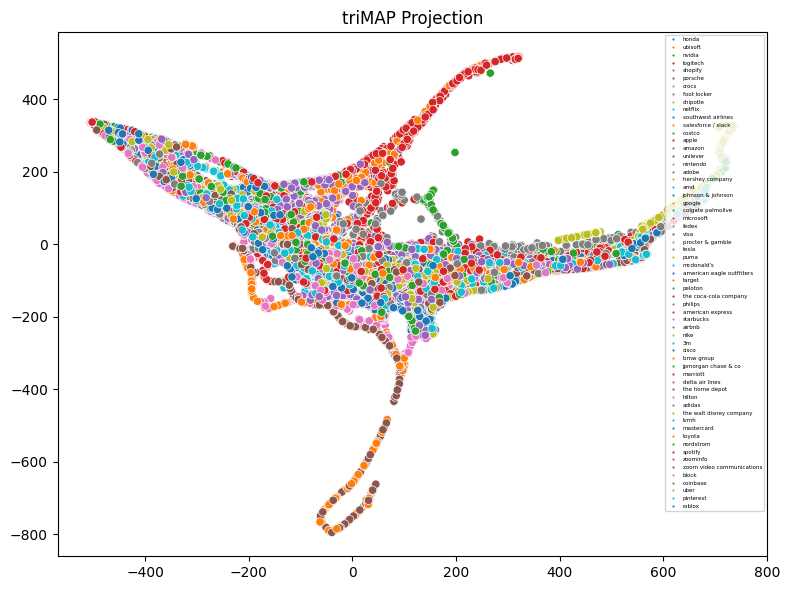

In [3]:
graphTriMAP(X_test,Y_test)

We see apple stock in the triMAP grouping also creating what appears to be a distinct subgrouping

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

centers = 8
n_clusters = 8
df = pd.DataFrame(X_test)

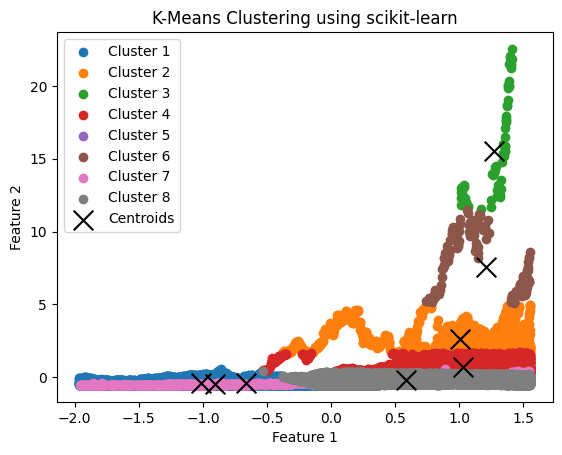

In [9]:
# Create and fit K-Means model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(df)

# Get results
labels = kmeans.labels_                 # Cluster assignment for each point
centroids = kmeans.cluster_centers_     # Final centroid positions

# Plot the clustering result
for i in range(centers):
    # Use .loc with the boolean mask and then select the desired columns
    cluster_data = df.loc[labels == i]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f"Cluster {i+1}")

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='x', label="Centroids")

plt.title("K-Means Clustering using scikit-learn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pacmap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from matplotlib.patches import Circle

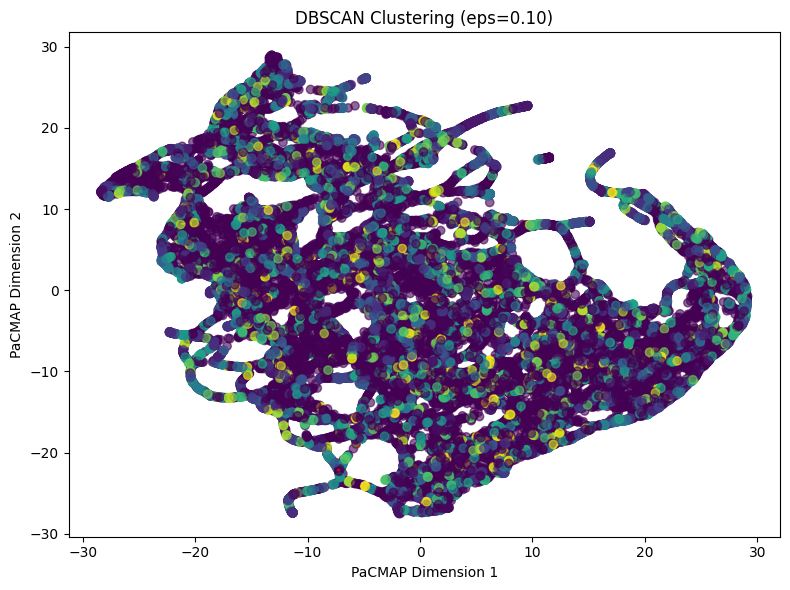

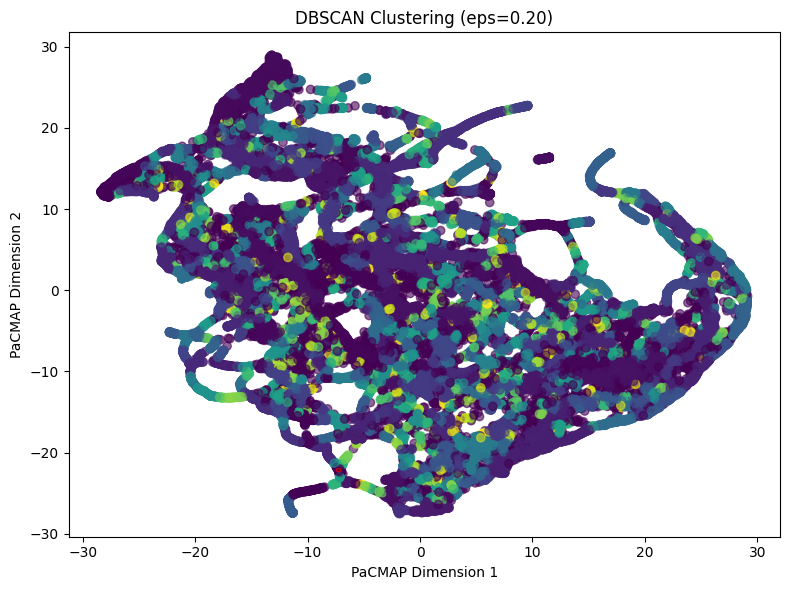

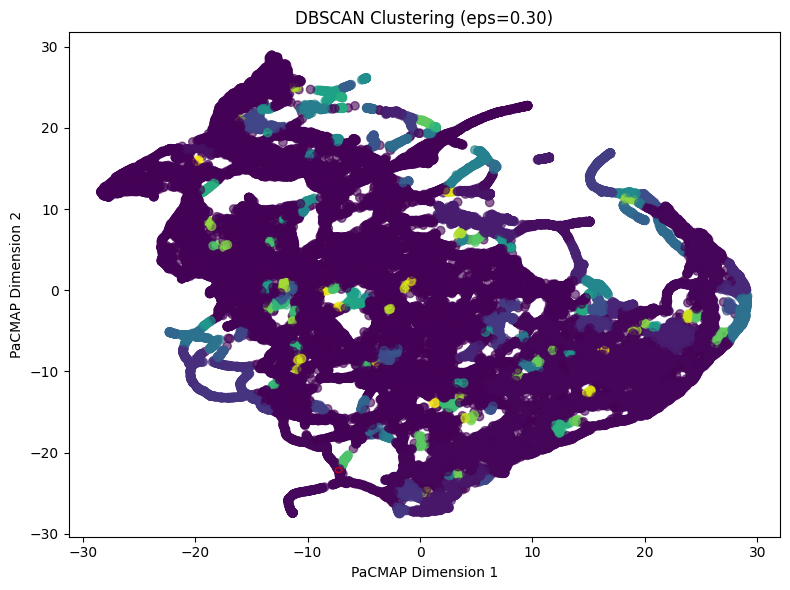

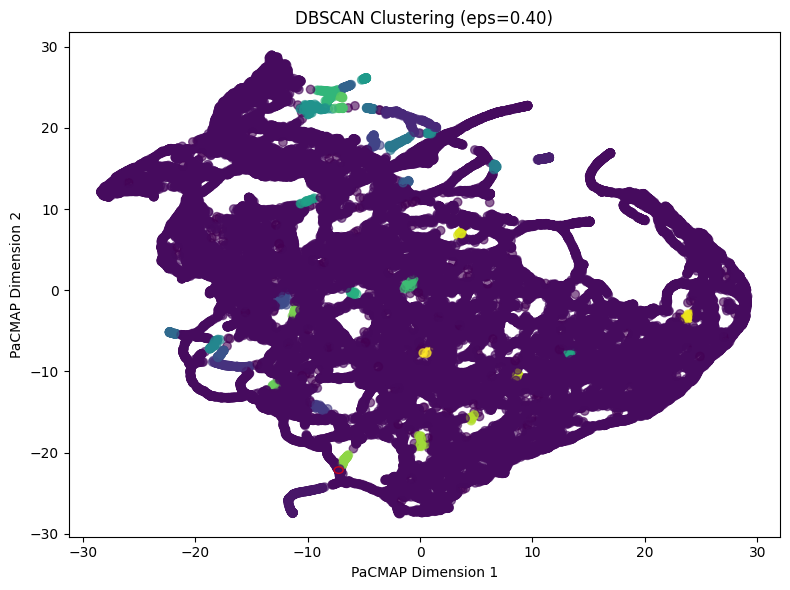

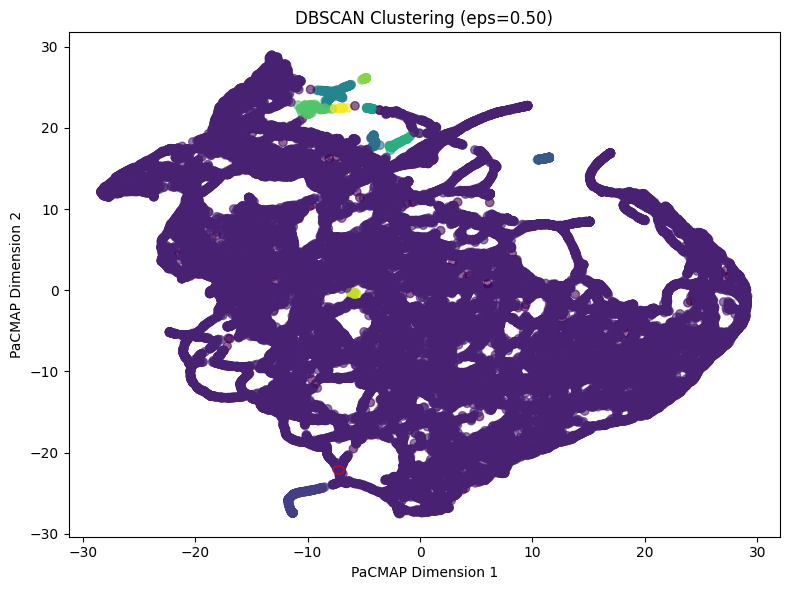

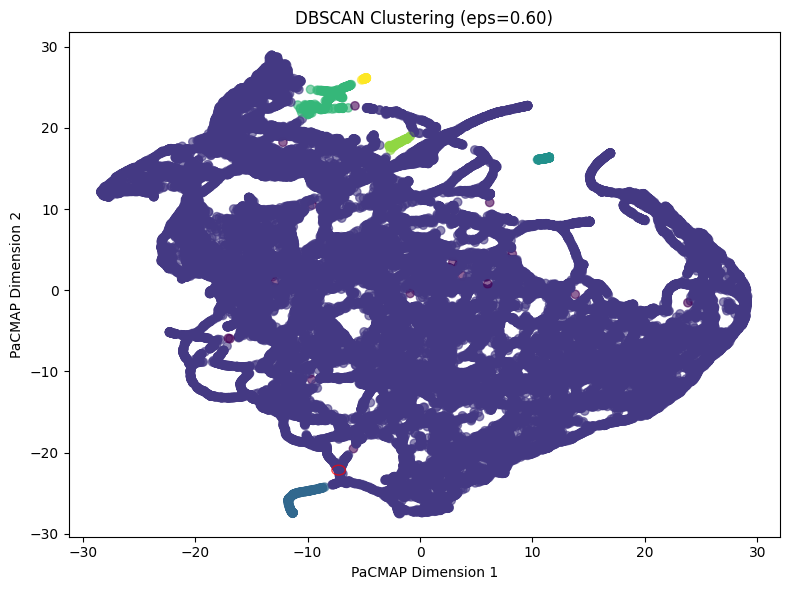

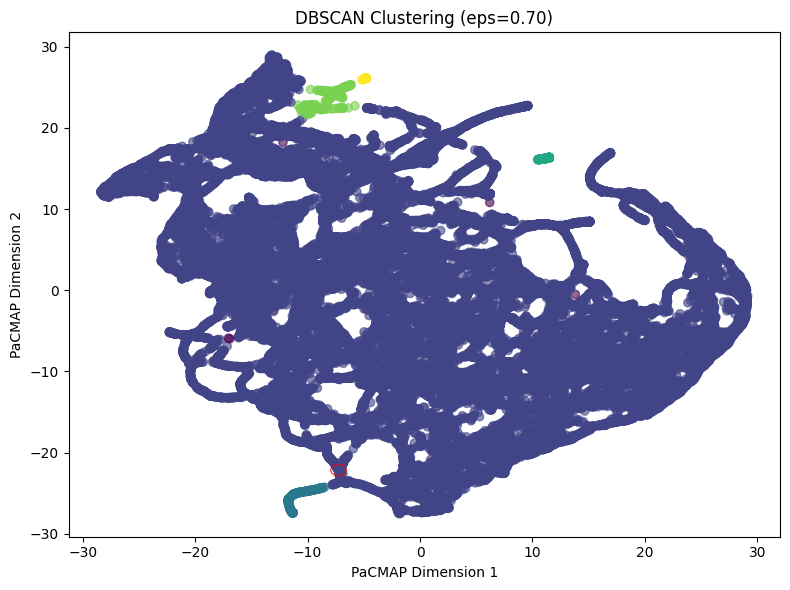

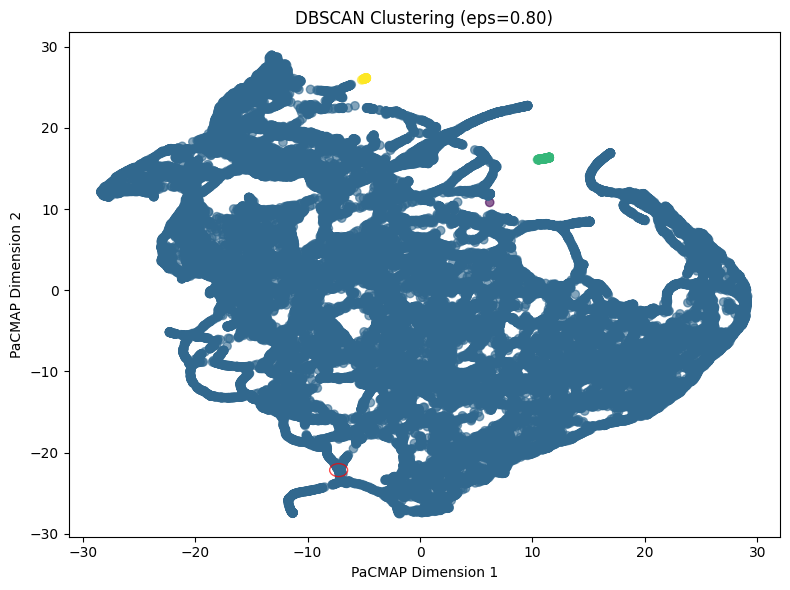

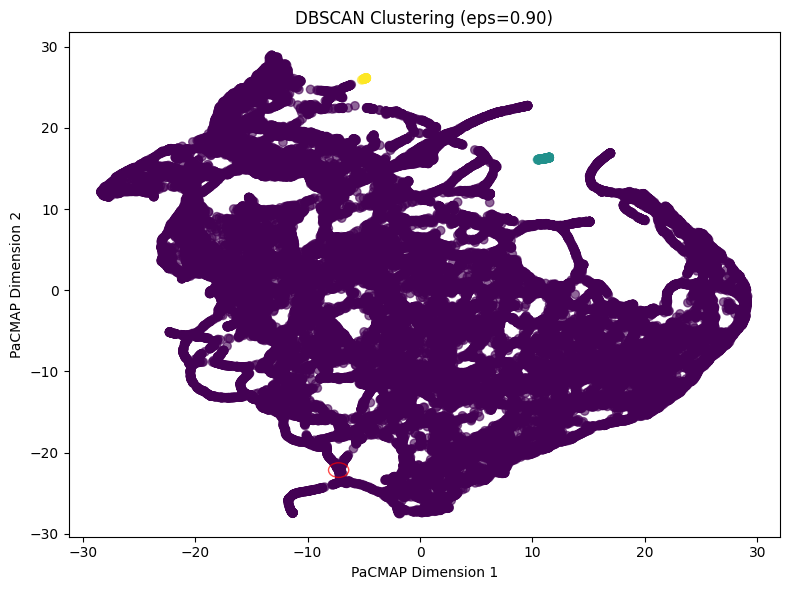

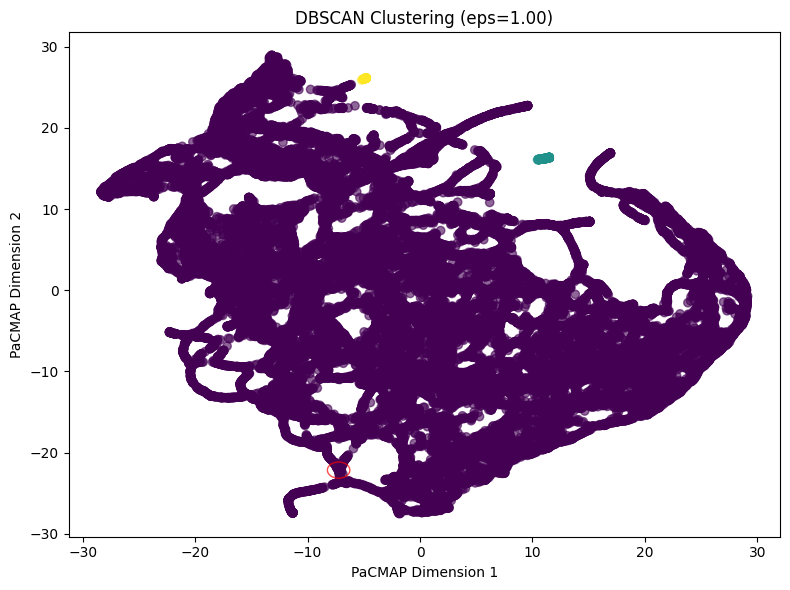

In [11]:
# Apply PaCMAP for dimensionality reduction
def apply_pacmap(data):
    reducer = pacmap.PaCMAP(n_components=2)
    return reducer.fit_transform(data)

# Plot at each iteration (no animation)
def plot_each_iteration(embedding, min_iter, max_iter, step):
    # Run DBSCAN once to pick a fixed core point (avoid noise)
    dbscan_init = DBSCAN(eps=min_iter, min_samples=5)
    labels_init = dbscan_init.fit_predict(embedding)

    core_indices = np.where(labels_init != -1)[0]
    if len(core_indices) > 0:
        fixed_index = core_indices[0]  # Choose the first core point
    else:
        fixed_index = np.random.randint(0, len(embedding))  # Fallback: pick any point if no core found

    fixed_point = embedding[fixed_index]

    for eps in np.arange(min_iter, max_iter + step, step):
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(embedding)

        plt.figure(figsize=(8, 6))
        plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", alpha=0.6)

        # Draw a single circle around the fixed core point
        circle = Circle((fixed_point[0], fixed_point[1]), eps, color="red", fill=False, alpha=0.7)
        plt.gca().add_patch(circle)

        plt.title(f"DBSCAN Clustering (eps={eps:.2f})")
        plt.xlabel("PaCMAP Dimension 1")
        plt.ylabel("PaCMAP Dimension 2")
        plt.tight_layout()
        plt.show()

#############################################################################################
# Main execution

embedding = apply_pacmap(df)

# Define DBSCAN iteration range and interval
min_iter = 0.1  # Starting eps
max_iter = 1.0  # Ending eps
step = 0.1      # Step size

plot_each_iteration(embedding, min_iter, max_iter, step)
#############################################################################################


In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import Birch

In [4]:


model = Birch(n_clusters=None, threshold=1.5, branching_factor=50)
model.fit(X_test)


yhat = model.predict(X_test)



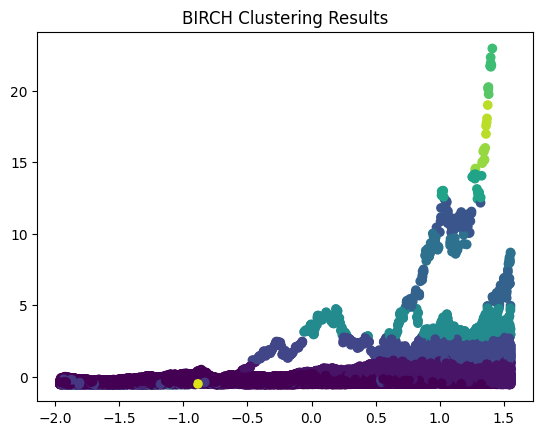

In [7]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=yhat, cmap='viridis')
plt.title('BIRCH Clustering Results')
plt.show()